<a href="https://colab.research.google.com/github/GH-Rumi/PemMes_7_Helmi/blob/main/JS05/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas Lab 1**

**1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

**2. Load dan Preprocessing Data**

In [13]:
df = pd.read_csv('voice.csv')

# Mengubah label teks menjadi angka (male=1, female=0)
df['label'] = df['label'].map({'male': 1, 'female': 0})

# Memisahkan fitur (X) dan label (y)
X = df.drop('label', axis=1)
y = df['label']

# Standarisasi data (PENTING untuk algoritma kNN)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,1
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,1
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,1
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,1
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,1


**3. Ekstraksi Fitur Paling Optimal**

In [14]:
# Menggunakan Random Forest untuk melihat tingkat kepentingan fitur
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y)

# Mengurutkan fitur dari yang paling penting
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Mengambil 7 fitur terbaik (berdasarkan hasil evaluasi optimal kita sebelumnya)
best_features = importances.head(7).index.tolist()
print(f"Fitur optimal yang digunakan: {best_features}\n")

# Menggunakan subset data dengan fitur terbaik saja
X_best = X_scaled[best_features]

# Split data training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.2, random_state=42)

Fitur optimal yang digunakan: ['meanfun', 'IQR', 'Q25', 'sd', 'sp.ent', 'sfm', 'centroid']



**4. Mencari Nilai K Terbaik dan Evaluasi**

In [15]:
k_values = range(1, 31)
k_accuracies = []

# Melakukan perulangan untuk K = 1 hingga 30
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    k_accuracies.append(acc)

# Mencari nilai K dengan akurasi tertinggi
best_k = k_values[np.argmax(k_accuracies)]
best_acc = max(k_accuracies)

print(f"Nilai K terbaik: {best_k}")
print(f"Akurasi terbaik: {best_acc:.4f} ({best_acc * 100:.2f}%)")

Nilai K terbaik: 9
Akurasi terbaik: 0.9858 (98.58%)


**5. Visualisasi Grafik**

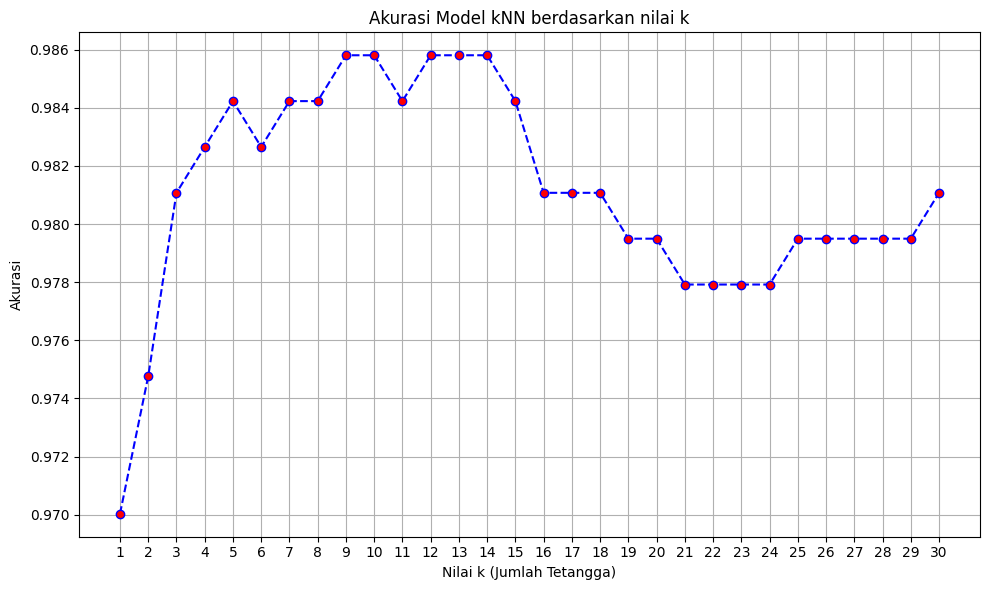

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, k_accuracies, marker='o', linestyle='dashed', color='blue', markerfacecolor='red')
plt.title('Akurasi Model kNN berdasarkan nilai k')
plt.xlabel('Nilai k (Jumlah Tetangga)')
plt.ylabel('Akurasi')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()